# APT_Data_Prep EDA (탐색적 데이터 분석)

서울 아파트 거래 데이터에 대한 탐색적 데이터 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한국어 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv('data/APT_Data_Prep.csv')
print(f"데이터 로드 완료: {df.shape[0]:,}행 × {df.shape[1]}열")

데이터 로드 완료: 220,890행 × 17열


In [2]:
# 데이터 구조 확인
print("=== Shape ===")
print(df.shape)
print("\n=== Dtypes ===")
print(df.dtypes)
print("\n=== 처음 5행 ===")
df.head()

=== Shape ===
(220890, 17)

=== Dtypes ===
거래금액    float64
단지명      object
시도명      object
시군구      object
법정동      object
지번       object
입주년도      int64
계약년도      int64
계약월       int64
계약일       int64
전용면적    float64
층         int64
경과년수      int64
재건축      object
계약일자     object
세대수       int64
주차대수      int64
dtype: object

=== 처음 5행 ===


,거래금액,단지명,시도명,시군구,법정동,지번,입주년도,계약년도,계약월,계약일,전용면적,층,경과년수,재건축,계약일자,세대수,주차대수
0,10.05,삼익대청아파트,서울특별시,강남구,개포동,12,1992,2020,1,31,39.53,13,28,부족,2020-01-31,822,700
1,20.30,개포자이,서울특별시,강남구,개포동,12-2,2004,2020,1,6,134.30,17,16,부족,2020-01-06,212,502
2,18.00,개포주공6단지,서울특별시,강남구,개포동,185,1983,2020,1,14,60.13,14,37,충족,2020-01-14,1060,300
3,28.50,디에이치아너힐즈,서울특별시,강남구,개포동,1281,2019,2020,1,4,94.29,12,1,부족,2020-01-04,1320,2120
4,17.10,개포주공7단지,서울특별시,강남구,개포동,185,1983,2020,1,12,60.76,2,37,충족,2020-01-12,1060,300


In [3]:
# 결측값 현황
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측수': missing, '결측률(%)': missing_pct})
missing_result = missing_df[missing_df['결측수'] > 0].sort_values('결측률(%)', ascending=False)

if len(missing_result) > 0:
    print(f"결측값이 있는 컬럼: {len(missing_result)}개")
    display(missing_result)
else:
    print("결측값 없음")

결측값 없음


In [4]:
# 수치형 기술통계
df.describe()

,거래금액,입주년도,계약년도,계약월,계약일,전용면적,층,경과년수,세대수,주차대수
count,220890.000000,220890.000000,220890.000000,220890.000000,220890.000000,220890.000000,220890.000000,220890.000000,220890.000000,220890.000000
mean,10.111720,2002.322215,2021.735869,6.221241,15.823908,75.471219,9.534578,19.413654,1065.668079,1175.280823
std,7.461396,10.396538,1.643023,3.134888,8.666083,30.573625,6.370747,10.336370,1253.131045,1614.546846
min,0.620000,1961.000000,2020.000000,1.000000,1.000000,10.780000,-3.000000,-2.000000,1.000000,0.000000
25%,5.700000,1996.000000,2020.000000,4.000000,8.000000,59.640000,5.000000,12.000000,259.000000,241.000000
50%,8.300000,2002.000000,2021.000000,6.000000,16.000000,79.200000,9.000000,20.000000,668.000000,654.000000
75%,12.400000,2010.000000,2023.000000,8.000000,23.000000,84.960000,13.000000,26.000000,1372.000000,1401.000000
max,220.000000,2024.000000,2024.000000,12.000000,31.000000,317.360000,68.000000,60.000000,9510.000000,12602.000000


In [5]:
# 범주형 변수 확인
cat_cols = df.select_dtypes(include='object').columns
print(f"범주형 컬럼: {len(cat_cols)}개\n")

for col in cat_cols:
    print(f"=== {col} (unique: {df[col].nunique()}) ===")
    print(df[col].value_counts().head(10))
    print()

범주형 컬럼: 7개

=== 단지명 (unique: 6191) ===
단지명
현대           1928
두산           1679
벽산           1273
신동아          1170
주공2          1077
한신           1074
파크리오          987
삼성래미안         977
헬리오시티         954
에스케이북한산시티     908
Name: count, dtype: int64

=== 시도명 (unique: 1) ===
시도명
서울특별시    220890
Name: count, dtype: int64

=== 시군구 (unique: 25) ===
시군구
노원구     19204
송파구     14186
강서구     13610
강남구     12291
성북구     11995
강동구     11958
구로구     10966
영등포구    10486
서초구      9963
성동구      9228
Name: count, dtype: int64

=== 법정동 (unique: 332) ===
법정동
상계동    7130
중계동    4144
구로동    3997
봉천동    3970
신정동    3694
월계동    3099
서초동    3099
창동     3077
목동     2997
미아동    2970
Name: count, dtype: int64

=== 지번 (unique: 5131) ===
지번
1013    1111
17      1025
913      954
481      941
1353     908
10       869
13       843
688      813
22       783
1        777
Name: count, dtype: int64

=== 재건축 (unique: 2) ===
재건축
부족    183056
충족     37834
Name: count, dtype: int64

=== 계약일자 (unique: 1825) ===
계약일자
2020-0

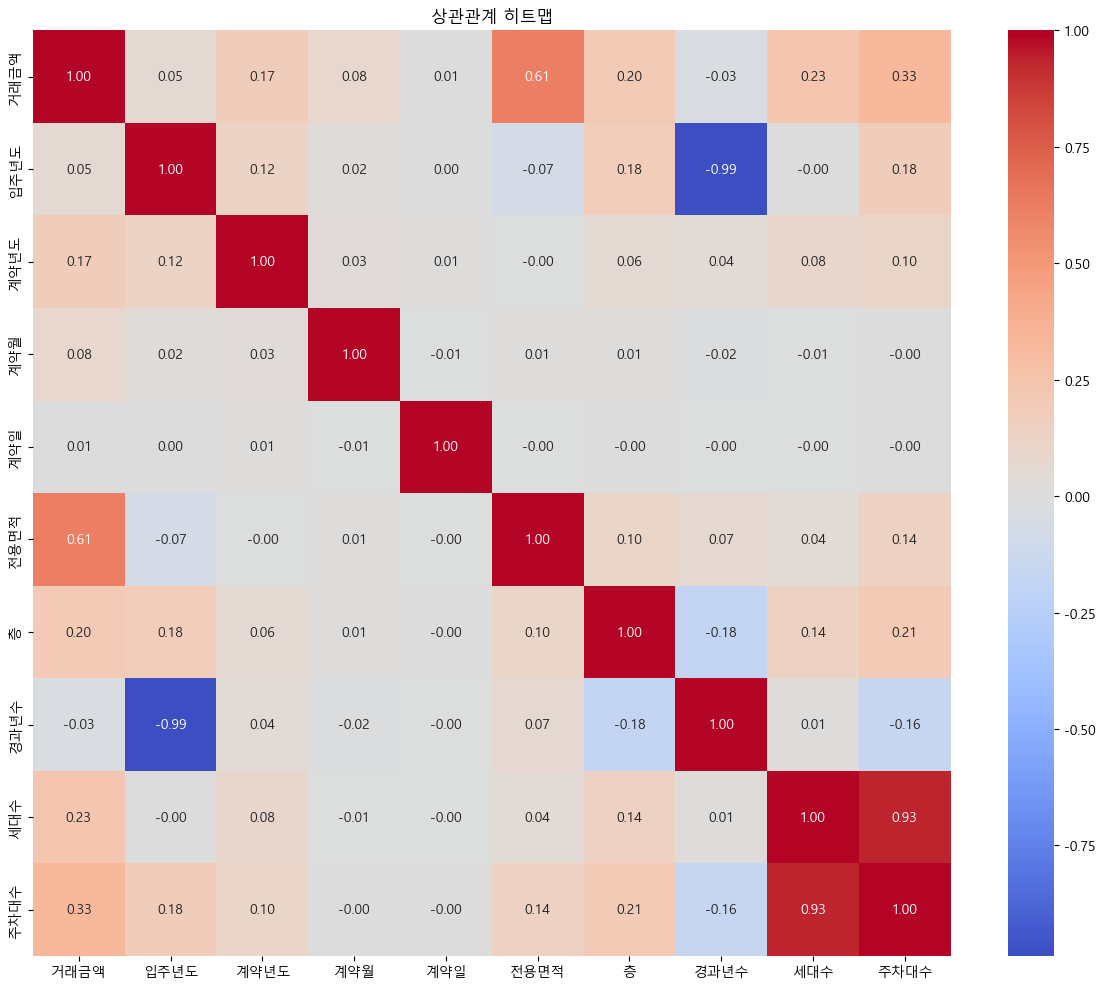

In [6]:
# 수치형 변수 상관관계 히트맵
num_cols = df.select_dtypes(include=np.number).columns
if len(num_cols) >= 2:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    ax.set_title('상관관계 히트맵')
    plt.tight_layout()
    plt.show()

In [ ]:
import hds

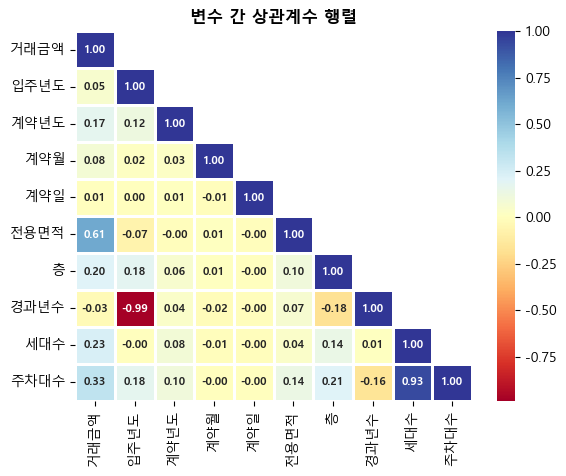

In [12]:
hds.plot.corr_heatmap(df)

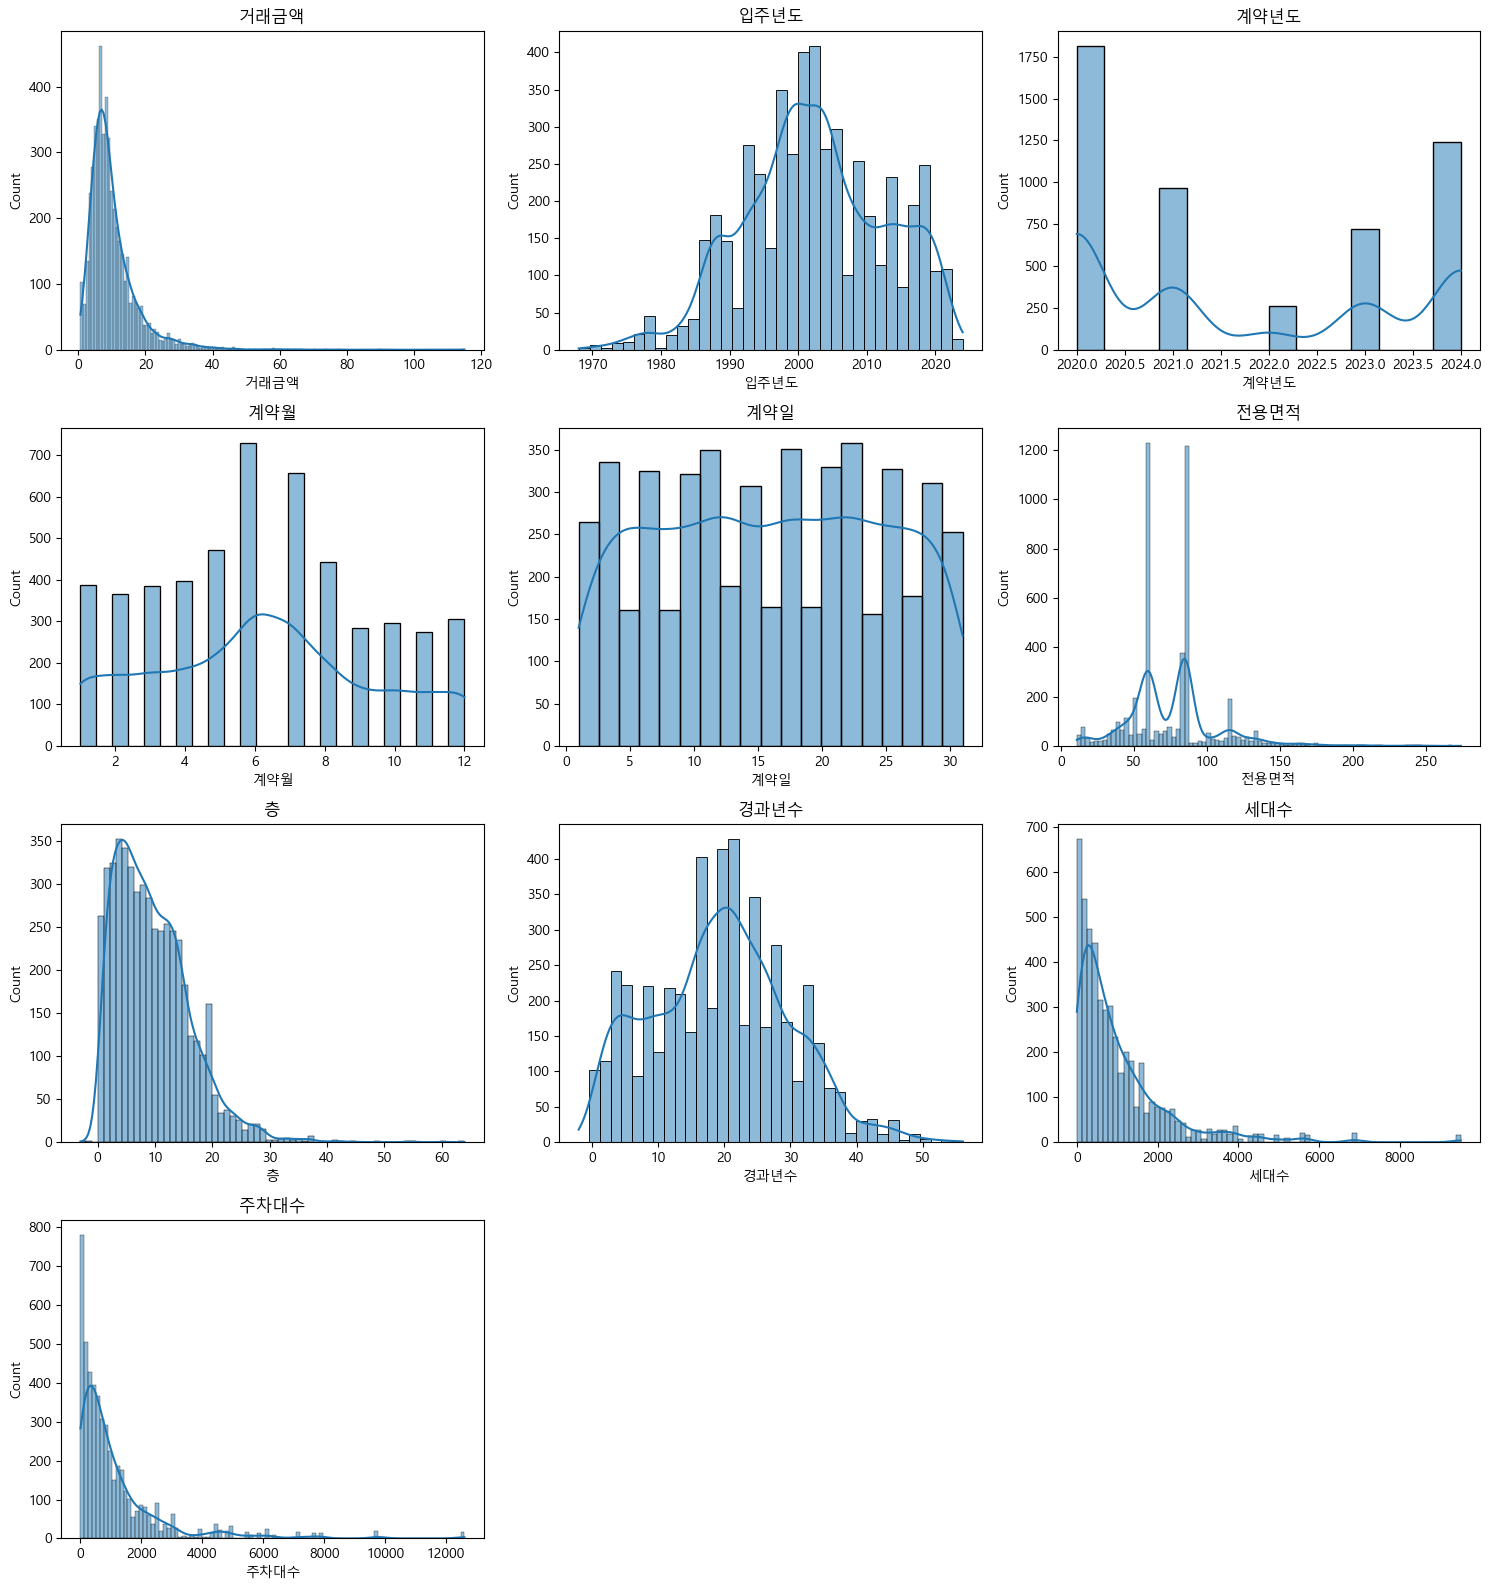

In [8]:
# 수치형 변수 분포 (22만 행 → sample 사용)
num_cols = df.select_dtypes(include=np.number).columns
n_cols = min(len(num_cols), 12)

if n_cols > 0:
    df_sample = df.sample(n=min(5000, len(df)), random_state=42)
    ncols_grid = 3
    nrows_grid = (n_cols + ncols_grid - 1) // ncols_grid
    fig, axes = plt.subplots(nrows=nrows_grid, ncols=ncols_grid, figsize=(15, 4 * nrows_grid))
    axes = axes.flatten()
    
    for i, col in enumerate(num_cols[:n_cols]):
        sns.histplot(df_sample[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_4140\961266906.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_gu.values, y=top_gu.index, ax=axes[1], palette='viridis')


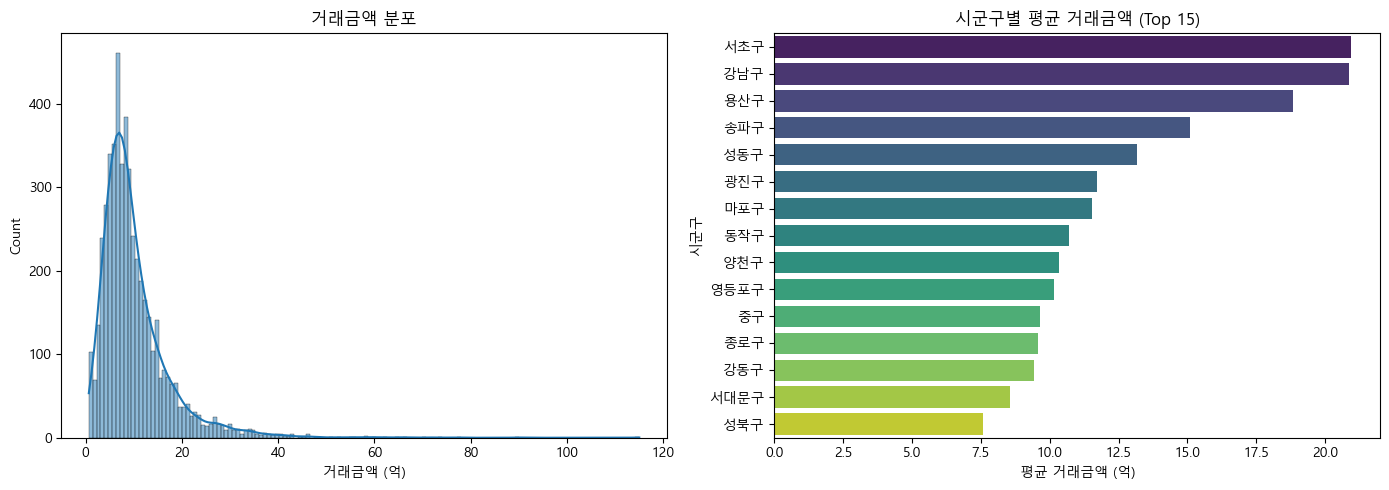

In [9]:
# 거래금액 분포 상세 (타겟 변수)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 분포
sns.histplot(df['거래금액'].sample(5000, random_state=42), kde=True, ax=axes[0])
axes[0].set_title('거래금액 분포')
axes[0].set_xlabel('거래금액 (억)')

# 시군구별 평균 거래금액
top_gu = df.groupby('시군구')['거래금액'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=top_gu.values, y=top_gu.index, ax=axes[1], palette='viridis')
axes[1].set_title('시군구별 평균 거래금액 (Top 15)')
axes[1].set_xlabel('평균 거래금액 (억)')

plt.tight_layout()
plt.show()

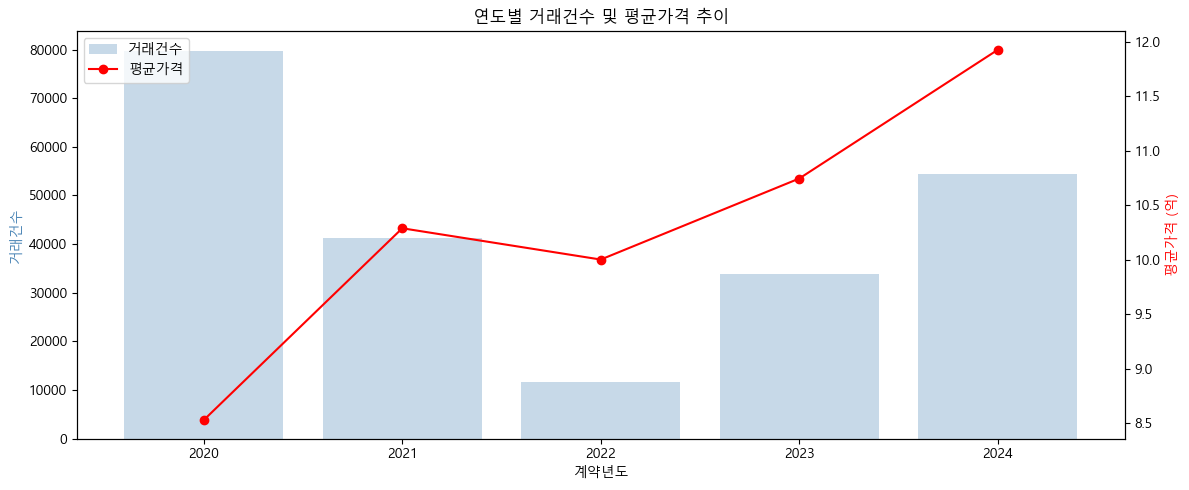

In [10]:
# 연도별 거래 추이
yearly = df.groupby('계약년도').agg(
    거래건수=('거래금액', 'count'),
    평균가격=('거래금액', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(yearly['계약년도'], yearly['거래건수'], alpha=0.3, color='steelblue', label='거래건수')
ax2.plot(yearly['계약년도'], yearly['평균가격'], color='red', marker='o', label='평균가격')

ax1.set_xlabel('계약년도')
ax1.set_ylabel('거래건수', color='steelblue')
ax2.set_ylabel('평균가격 (억)', color='red')
ax1.set_title('연도별 거래건수 및 평균가격 추이')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()